Problem Statement:

Build a Multi-Class ANN Classifier — Build an ANN in Keras with this exact architecture: Dense(32, activation="relu") → Dense(16, activation="relu") → Dense(n_classes, activation="softmax"). Label-encode the target if it is text, compile with the Adam optimizer and sparse_categorical_crossentropy loss, train for about 30 epochs, and report test accuracy. Plot the training vs. validation accuracy and loss curves. In 1-2 sentences, explain why this problem needs a Softmax outp Load the CSV file (a random 5,000-row sample is plenty), separate the label column, reshape the remaining 784 pixel columns to 28×28×1 per row, and normalize pixel values to 0-1 (divide by 255). Build this exact CNN in Keras: Conv2D(32, 3x3, activation="relu") → MaxPooling2D → Conv2D(64, 3x3, activation="relu") → MaxPooling2D → Flatten → Dense(64, activation="relu") → Dense(n_classes, activation="softmax"). Train for 5 epochs and report test accuracy. Display 5 sample test images next to their true and predicted labels.ut layer instead of a single Sigmoid neuron.

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

In [50]:
df = pd.read_csv('/content/Iris.csv')
df.shape

(150, 6)

In [51]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [52]:
df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [54]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [55]:
df = df.drop(columns=["Id"])

In [56]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [57]:
df.Species.value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [58]:
df.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [59]:
numeric_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

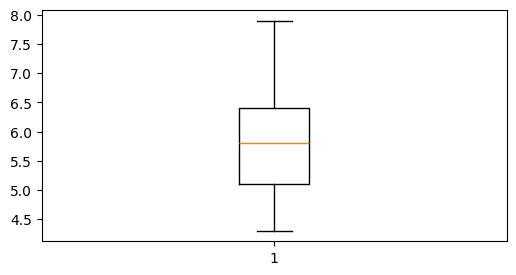

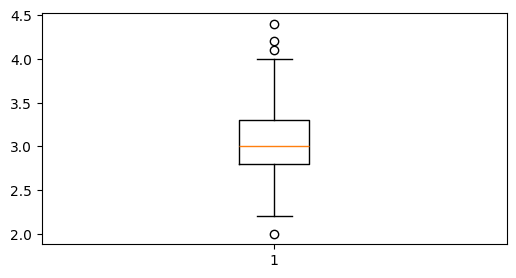

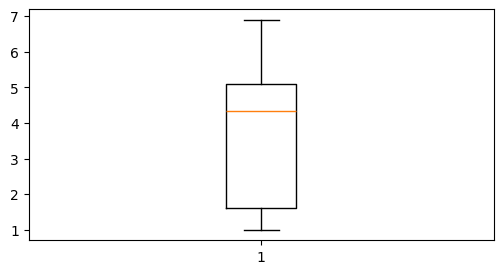

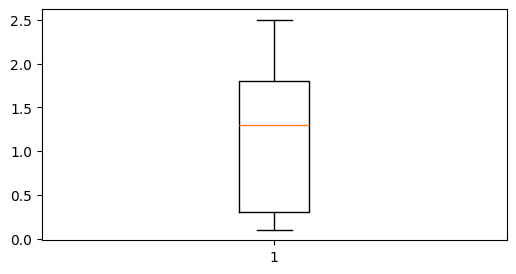

In [60]:
for col in numeric_columns:
  plt.figure(figsize=(6, 3))
  plt.boxplot(df[col])
  plt.show()

In [61]:
for col in numeric_columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3-Q1

  lower_bound = Q1-1.5*IQR
  upper_bound = Q3+1.5*IQR

  df[col] = df[col].clip(lower = lower_bound, upper = upper_bound)

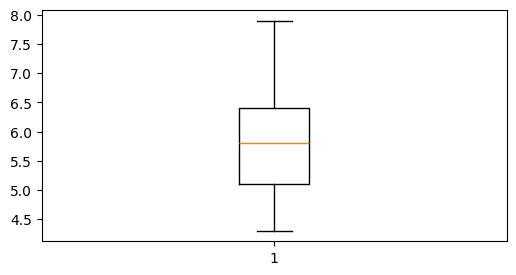

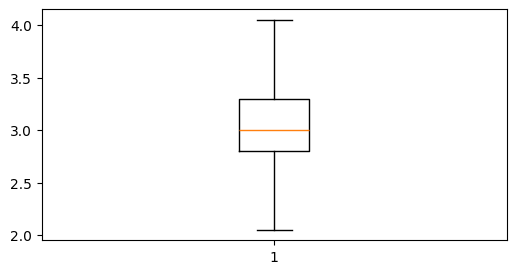

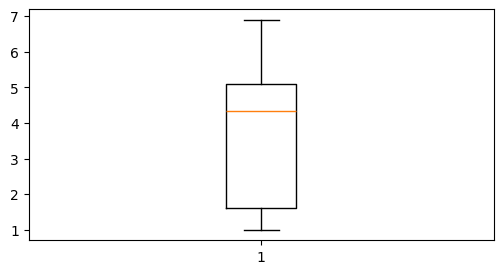

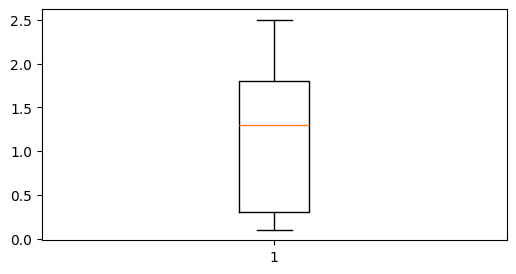

In [62]:
for col in numeric_columns:
  plt.figure(figsize=(6, 3))
  plt.boxplot(df[col])
  plt.show()

In [63]:
# encoding diagnosis column

le = LabelEncoder()
df["Species"] = le.fit_transform(df["Species"])

In [64]:
df.Species.value_counts()

,count
Species,
0,50
1,50
2,50


In [65]:
# Feature Selection

X = df.drop(columns = ["Species"])
y = df["Species"]

In [66]:
# Train-Test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
# Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
# Build the model

model = Sequential([
    Input(shape = (4, )),
    Dense(32, activation = 'relu'),
    Dense(16, activation = 'relu'),
    Dense(3, activation = 'softmax')
])

In [69]:
# Compile the model

model.compile(
    loss = 'sparse_categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [70]:
# Train the model

history = model.fit(
    X_train_scaled,
    y_train,
    epochs = 30,
    batch_size = 8,
    validation_split = 0.2,
    verbose = 1
)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3125 - loss: 1.0999 - val_accuracy: 0.1667 - val_loss: 1.0654
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5625 - loss: 0.9932 - val_accuracy: 0.5000 - val_loss: 0.9769
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7188 - loss: 0.9026 - val_accuracy: 0.7083 - val_loss: 0.8917
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8125 - loss: 0.8203 - val_accuracy: 0.7917 - val_loss: 0.8126
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8333 - loss: 0.7409 - val_accuracy: 0.7917 - val_loss: 0.7406
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8333 - loss: 0.6653 - val_accuracy: 0.7917 - val_loss: 0.6751
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8229 - loss: 0.5983 - val_accuracy: 0.7917 - val_loss: 0.6168
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8229 - loss: 0.5448 - val_accuracy: 0.7917 - val_loss

In [71]:
# Evaluate the model

loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 1.0000 - loss: 0.1634


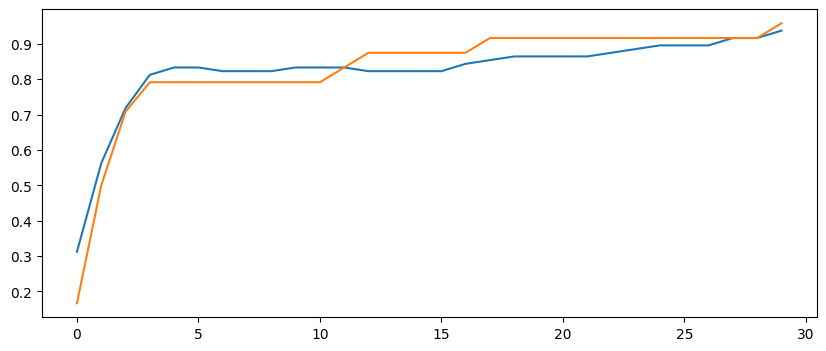

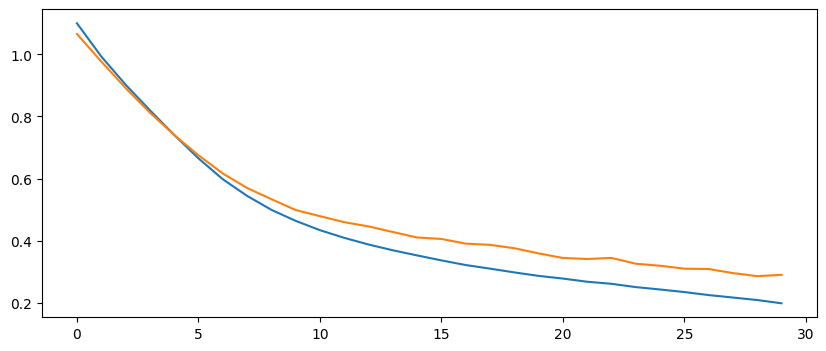

In [76]:
plt.figure(figsize = (10,4))
plt.plot(history.history['accuracy'],label = "train Acc")
plt.plot(history.history['val_accuracy'],label = "val Acc")

plt.figure(figsize = (10,4))
plt.plot(history.history['loss'],label = "train Loss")
plt.plot(history.history['val_loss'],label = "val Loss")


Softmax is required because this is a mutually exclusive multi-class classification task; it exponentiates and normalizes raw output logits into a valid probability distribution where each value is between 0 and 1 and all values sum to 1. This allows the network to output calibrated class probabilities for each category and properly calculate the multi-class cross-entropy loss (sparse_categorical_crossentropy).